# Configuración básica (no tocar)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from abstractions.base import Function
from abstractions.functions import Variable, sin, cos, exp, ln

In [2]:
x = Variable()

# Implementación de métodos

In [3]:
# Implementar para hallar raíces de las derivadas, no de f

def biseccion(f: Function, a: float, b: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()  # calcula f'
    # f'(a) y f'(b) deben tener signos opuestos para garantizar que hay un cero entre ellos
    if df.eval(a) * df.eval(b) >= 0:
        raise ValueError("f'(a) y f'(b) deben tener signos opuestos.")
    for step in range(1, max_iter + 1):
        mid = (a + b) / 2  # punto medio del intervalo
        df_mid = df.eval(mid)
        # se alcanzó la precisión deseada: f' ≈ 0 o el intervalo es suficientemente pequeño
        if abs(df_mid) < tol or (b - a) / 2 < tol:
            return mid, step
        # se achica el intervalo según el signo de f' en el punto medio
        if df.eval(a) * df_mid < 0:
            b = mid
        else:
            a = mid
    # se alcanzó el máximo de iteraciones sin converger
    return (a + b) / 2, max_iter

def newton(f: Function, x0: float, tol: float = 1e-6, max_iter: int = 1000):
    df  = f.derivative()   # calcula f'
    d2f = df.derivative()  # calcula f''
    xn  = x0
    for step in range(1, max_iter + 1):
        df_val  = df.eval(xn)
        d2f_val = d2f.eval(xn)
        # se alcanzó la precisión deseada: f' ≈ 0
        if abs(df_val) < tol:
            return xn, step
        # si f'' ≈ 0 no se puede dividir, el método no puede continuar
        if abs(d2f_val) < 1e-12:
            raise ValueError(f"f''({xn}) ≈ 0: Newton no puede continuar.")
        xn = xn - df_val / d2f_val  # actualización: x = x - f'(x)/f''(x)
    # se alcanzó el máximo de iteraciones sin converger
    return xn, max_iter

def descenso_gradiente(f: Function, x0: float, lr: float, tol: float = 1e-6, max_iter: int = 1000):
    df = f.derivative()  # calcula f'
    xn = x0
    for step in range(1, max_iter + 1):
        grad = df.eval(xn)
        # se alcanzó la precisión deseada: f' ≈ 0
        if abs(grad) < tol:
            return xn, step
        xn = xn - lr * grad  # actualización: x = x - lr * f'(x)
    # se alcanzó el máximo de iteraciones sin converger
    return xn, max_iter

### Prueba de métodos

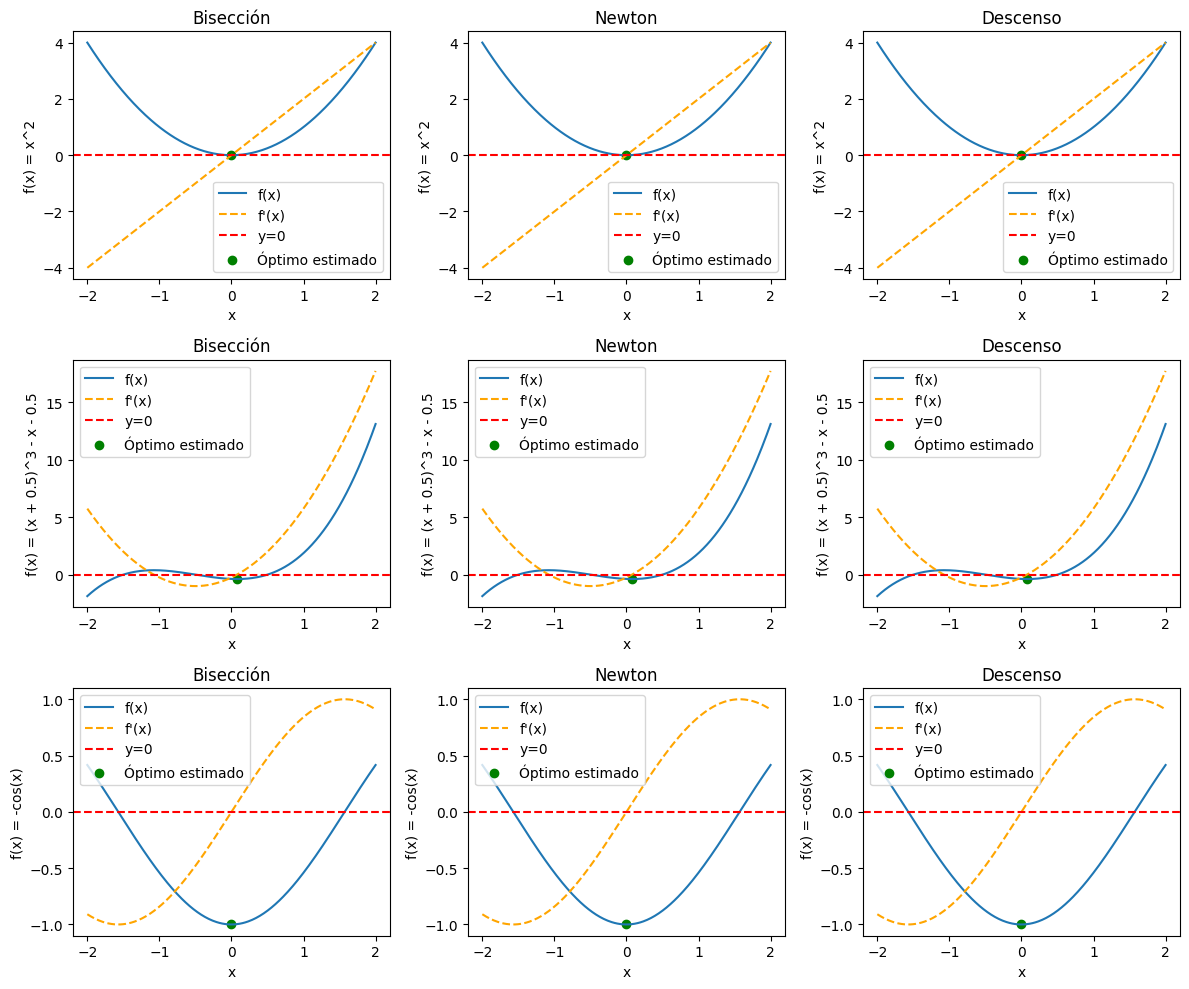

In [4]:
f1 = x**2
f2 = (x + 0.5)**3 - x - 0.5
f3 = -cos(x)

functions = [f1, f2, f3]

methods = [biseccion, newton, descenso_gradiente]
# Recomendación: exploren parámetros en esta etapa para ver distintos comportamientos.
parameters = [{"a":-1, "b":1}, {"x0": 1}, {"x0": 1, "lr": 1e-2}]

y_labels = ["f(x) = x^2", "f(x) = (x + 0.5)^3 - x - 0.5", "f(x) = -cos(x)"]
titles = ["Bisección", "Newton", "Descenso"]

lp = np.linspace(-2, 2, 300)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))

for i, f in enumerate(functions):
    for j, m in enumerate(methods):
        ax = axes[i, j]
        # labels ejes
        ax.set_xlabel("x")
        ax.set_ylabel(y_labels[i])

        # métodos
        method = methods[j]
        params = parameters[j] 
        res, step = method(f, **params)

        # graficas
        ax.plot(lp, np.array(list(map(lambda v: f.eval(v), lp))))
        ax.plot(lp, np.array(list(map(lambda v: f.derivative().eval(v), lp))), linestyle="--", color="orange")
        ax.axhline(0, linestyle="--", color="red")
        ax.scatter(res, f.eval(res), color="green")

        ax.plot()
        ax.legend([f"f(x)", "f'(x)", "y=0", "Óptimo estimado"])
        ax.set_title(titles[j])

plt.tight_layout()
plt.savefig("graficas/seccion2_verificacion.png", dpi=150, bbox_inches="tight")
plt.show()

# Aplicación a función no trivial

In [ ]:
f = x**2 + 2*sin(3*x)

In [ ]:
# Grafica de la función

In [ ]:
# Evaluación de métodos y generación de tablas

# Ajuste de datos

In [50]:
df_linear = pd.read_csv("datasets/linear_model.csv")
df_exp = pd.read_csv("datasets/exp_model.csv")
df_sin = pd.read_csv("datasets/sin_model.csv")

w = Variable()

In [ ]:
# Genere la función de pérdida

In [ ]:
# Optimice la función de pérdida

In [ ]:
# Grafique datos y ajuste

# BONUS: